In [20]:
import torch
from torchviz import make_dot
import torch.nn as nn
import matplotlib.pyplot as plt

In [7]:
x = [[1,2],[3,4],[5,6],[7,8]]
y = [[3],[7],[11],[15]]
# conjuntos simples para usar na rede

In [8]:
x= torch.tensor(x, dtype=torch.float32)
# transofrmo em tensores e em floats
y= torch.tensor(y, dtype=torch.float32)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [10]:
x = x.to(device)
y=y.to(device)

In [11]:
import torch.nn as nn


In [12]:
class rede(nn.Module):
    # faz uma redde bem simples para dar inicio a aula
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(2, 3)# define quantas features de entrada e quantas saidas
        self.activation = nn.ReLU()# define a funcao de ativacao que nao deixa passar valores negativos
        self.linear2 = nn.Linear(3, 1)# recebe as tres saidas da caamda anterior e gera uma saida

    def forward(self, x):
        # define a seuquencia das cmadas e das funcoes de ativacao dando como entrada os dados de treino
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        return x

In [13]:
model = rede()

In [14]:
make_dot(model(x), params=dict(list(model.named_parameters()))).render("rede", format="png")

'rede.png'

In [15]:
x.shape

torch.Size([4, 2])

In [16]:
model.linear1.weight

Parameter containing:
tensor([[ 0.2811,  0.6904],
        [-0.5541,  0.2485],
        [ 0.3793,  0.6054]], requires_grad=True)

In [17]:
loss = nn.MSELoss()# define a funcao de perda que sera usada para calcular o erro do modelo

In [18]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)# otimizador que sera usado para atualizar os pesos da rede

In [19]:
losses = []
for _ in range(50):
    optimizer.zero_grad()# zera os gradientes para nao acumular
    loss_value = loss(model(x), y)# calcula o erro do modelo

    loss_value.backward()# calcula os gradientes

    optimizer.step()# atualiza os pesos da rede
    losses.append(loss_value.detach().numpy())# armazena o erro do modelo

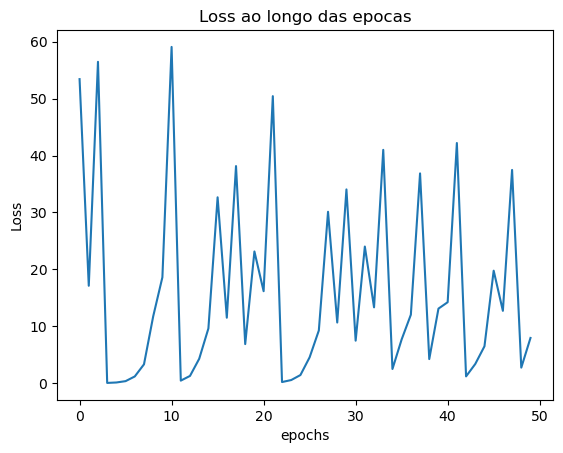

In [ ]:
plt.plot(losses)
plt.title('Loss ao longo das epocas')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.show()